In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "E:/icu_project/models/test_predictions.csv"
)

print(df.head())
print("Patients:", len(df))

   predicted_probability  true_label
0               0.028328         0.0
1               0.713363         0.0
2               0.018817         0.0
3               0.225931         0.0
4               0.508967         0.0
Patients: 2400


In [2]:
def risk_group(p):

    if p < 0.25:
        return "Low"

    elif p < 0.50:
        return "Moderate"

    elif p < 0.75:
        return "High"

    else:
        return "Critical"


df["risk_group"] = df["predicted_probability"].apply(risk_group)

df.head()

,predicted_probability,true_label,risk_group
0,0.028328,0.0,Low
1,0.713363,0.0,High
2,0.018817,0.0,Low
3,0.225931,0.0,Low
4,0.508967,0.0,High


In [3]:
df["risk_group"].value_counts()

risk_group
Low         1401
Moderate     423
High         402
Critical     174
Name: count, dtype: int64

In [4]:
mortality = df.groupby("risk_group")["true_label"].mean()

print(mortality)

risk_group
Critical    0.580460
High        0.286070
Low         0.039971
Moderate    0.163121
Name: true_label, dtype: float64


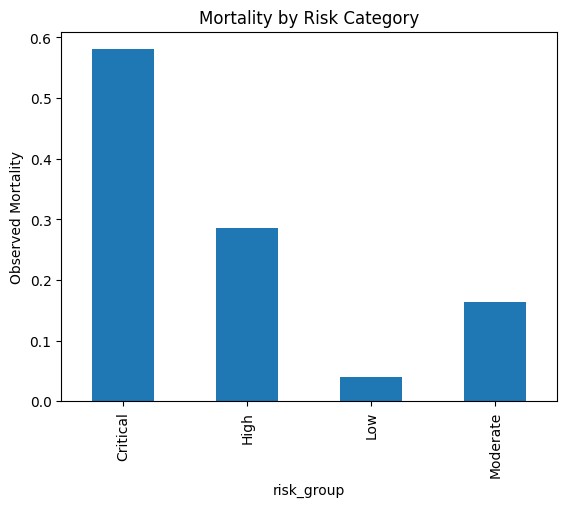

In [5]:
mortality.plot(kind="bar")

plt.ylabel("Observed Mortality")
plt.title("Mortality by Risk Category")

plt.show()

In [6]:
df_sorted = df.sort_values(
    "predicted_probability",
    ascending=False
)

icu_capacity = int(len(df) * 0.25)

icu_patients = df_sorted.head(icu_capacity)

print("ICU capacity:", icu_capacity)

ICU capacity: 600


In [7]:
icu_mortality = icu_patients["true_label"].mean()

print("Mortality among high-risk ICU group:", icu_mortality)

Mortality among high-risk ICU group: 0.365


In [8]:
random_group = df.sample(icu_capacity)

random_mortality = random_group["true_label"].mean()

print("Mortality with random allocation:", random_mortality)

Mortality with random allocation: 0.13833333333333334


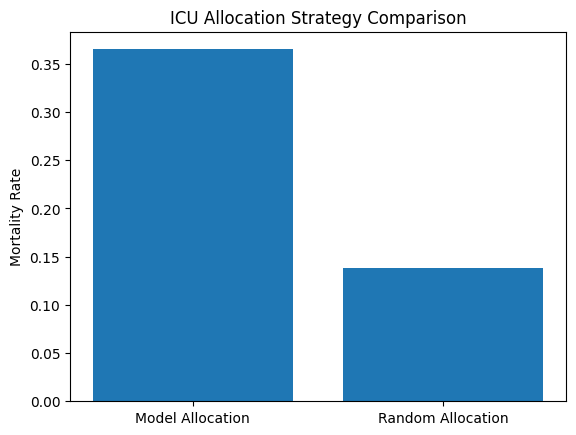

In [9]:
plt.bar(
    ["Model Allocation","Random Allocation"],
    [icu_mortality, random_mortality]
)

plt.ylabel("Mortality Rate")
plt.title("ICU Allocation Strategy Comparison")

plt.show()

In [10]:
df.to_csv(
    "E:/icu_project/models/triage_simulation_results.csv",
    index=False
)